In [1]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import numpy as np
from matplotlib import cm, colors

### Helping Functions

In [2]:
def load_img(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return np.asarray(Image.open(path))


def show_img(ax, img, title=None, panel_label=None):
    ax.imshow(img)
    ax.axis("off")

    if title is not None:
        ax.set_title(title, fontsize=11, pad=4)

    if panel_label is not None:
        ax.text(
            0.01, 0.99,
            panel_label,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=13,
            fontweight="bold",
            color="black",
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=2)
        )
        
        
        
def show_panel(fig, img, rect):
    ax = fig.add_axes(rect)
    ax.imshow(img, aspect="auto")
    ax.axis("off")
    return ax


def show_zoom_panel(fig, img, rect):
    ax = fig.add_axes(rect)
    ax.imshow(img, origin="upper", aspect="equal")
    ax.axis("off")
    return ax

def show_panel_keep_aspect(fig, img, rect):
    ax = fig.add_axes(rect)
    ax.imshow(img, origin="lower", aspect="equal")
    ax.axis("off")
    return ax


def crop_to_box_aspect_bottom_left(img, rect):
    """
    Crop image to match target rect aspect ratio.
    Always keeps the bottom-left corner fixed.
    
    This is useful when the axis origin is at the lower-left corner
    and should stay aligned with the displayed panel.
    """
    h, w = img.shape[:2]

    target_ratio = rect[2] / rect[3]   # box width / box height
    img_ratio = w / h

    if img_ratio > target_ratio:
        # image too wide -> crop from the RIGHT
        new_w = int(round(h * target_ratio))
        return img[:, :new_w]

    else:
        # image too tall -> crop from the TOP
        new_h = int(round(w / target_ratio))
        return img[h - new_h:, :]
    
    
    
def crop_to_box_aspect_left_center_y(img, rect):
    """
    Crop image to match target rect aspect ratio.
    Keeps left edge fixed for x-alignment.
    If height needs cropping, crop symmetrically around vertical center.
    """
    h, w = img.shape[:2]

    target_ratio = rect[2] / rect[3]   # box width / box height
    img_ratio = w / h

    if img_ratio > target_ratio:
        # image too wide -> crop from RIGHT, keep left edge
        new_w = int(round(h * target_ratio))
        return img[:, :new_w]

    else:
        # image too tall -> crop TOP/BOTTOM symmetrically, keep center
        new_h = int(round(w / target_ratio))
        y0 = ((h - new_h) // 2)
        return img[y0:y0 + new_h, :]

    

def crop_fixed_margins(img, left=0, right=0, top=0, bottom=0):
    """
    Crops the same fixed pixel margins from all sides.
    """
    h, w = img.shape[:2]
    return img[top:h-bottom, left:w-right]



def draw_axis_icon_equal(ax, fig, 
                         x0=0, y0=0,
                         arrow_len_in=0.22,
                         fontsize=15, lw=2.0,
                         color="black",
                         label_pad_in=0.03):
    """
    Draw x-z axis icon with equal physical arrow length in both directions,
    independent of panel shape.

    Parameters
    ----------
    ax : matplotlib axis
    fig : matplotlib figure
    x0, y0 : float
        Start point in axes-fraction coordinates.
    arrow_len_in : float
        Desired arrow length in inches on the final figure.
    fontsize : int
    lw : float
    color : str
    label_pad_in : float
        Extra distance of labels from arrow tips, in inches.
    """
    # axis size in inches
    bbox = ax.get_position()
    fig_w, fig_h = fig.get_size_inches()

    ax_w_in = bbox.width * fig_w
    ax_h_in = bbox.height * fig_h

    # convert desired physical length to axes fractions
    dx = arrow_len_in / ax_w_in
    dz = arrow_len_in / ax_h_in

    # convert label pad to axes fractions
    pad_x = label_pad_in / ax_w_in
    pad_z = label_pad_in / ax_h_in

    # x arrow
    ax.annotate(
        "",
        xy=(x0 + dx, y0),
        xytext=(x0, y0),
        xycoords="axes fraction",
        arrowprops=dict(
            arrowstyle="-|>",
            color=color,
            lw=lw,
            shrinkA=0,
            shrinkB=0,
            mutation_scale=fontsize
        )
    )

    # z arrow
    ax.annotate(
        "",
        xy=(x0, y0 + dz),
        xytext=(x0, y0),
        xycoords="axes fraction",
        arrowprops=dict(
            arrowstyle="-|>",
            color=color,
            lw=lw,
            shrinkA=0,
            shrinkB=0,
            mutation_scale=fontsize
        )
    )

    # labels
    ax.text(
        x0 + dx + pad_x, y0 - 0.07,
        "x",
        transform=ax.transAxes,
        ha="left", va="center",
        fontsize=fontsize, color=color
    )

    ax.text(
        x0 - 0.015, y0 + dz + pad_z,
        "z",
        transform=ax.transAxes,
        ha="center", va="bottom",
        fontsize=fontsize, color=color
    )
    
    
    
    
def draw_axis_icon_equal_zoom(ax, fig, 
                         x0=0, y0=0,
                         arrow_len_in=0.22,
                         fontsize=15, lw=2.0,
                         color="black",
                         label_pad_in=0.03):
    """
    Draw x-z axis icon with equal physical arrow length in both directions,
    independent of panel shape.

    Parameters
    ----------
    ax : matplotlib axis
    fig : matplotlib figure
    x0, y0 : float
        Start point in axes-fraction coordinates.
    arrow_len_in : float
        Desired arrow length in inches on the final figure.
    fontsize : int
    lw : float
    color : str
    label_pad_in : float
        Extra distance of labels from arrow tips, in inches.
    """
    # axis size in inches
    bbox = ax.get_position()
    fig_w, fig_h = fig.get_size_inches()

    ax_w_in = bbox.width * fig_w
    ax_h_in = bbox.height * fig_h

    # convert desired physical length to axes fractions
    dx = arrow_len_in / ax_w_in
    dz = arrow_len_in / ax_h_in

    # convert label pad to axes fractions
    pad_x = label_pad_in / ax_w_in
    pad_z = label_pad_in / ax_h_in

    # x arrow
    ax.annotate(
        "",
        xy=(x0 + dx, y0),
        xytext=(x0, y0),
        xycoords="axes fraction",
        arrowprops=dict(
            arrowstyle="-|>",
            color=color,
            lw=lw,
            shrinkA=0,
            shrinkB=0,
            mutation_scale=fontsize
        )
    )

    # z arrow
    ax.annotate(
        "",
        xy=(x0, y0 + dz),
        xytext=(x0, y0),
        xycoords="axes fraction",
        arrowprops=dict(
            arrowstyle="-|>",
            color=color,
            lw=lw,
            shrinkA=0,
            shrinkB=0,
            mutation_scale=fontsize
        )
    )

    # labels
    ax.text(
        x0 + dx + pad_x, y0 - 0.05,
        "x",
        transform=ax.transAxes,
        ha="left", va="center",
        fontsize=fontsize, color=color
    )

    ax.text(
        x0 - 0.05, y0 + dz + pad_z,
        "z",
        transform=ax.transAxes,
        ha="center", va="bottom",
        fontsize=fontsize, color=color
    )

### Subexp01 with condition = "70vs50"

In [3]:
base_dir = Path("../../figures/subexp01/individual")
fourier_dir = Path("../../figures/subexp01/fourier_panels")  # falls du so einen Ordner hast

angle = 70
condition = "70° refined"
case_name = f"subexp01_{angle}_vs_50_difference_maps"


paths = {
    "XY": base_dir / "subexp01_abs_overlay_XY_70_vs_50_natural_aspect.png",
    "XZ": base_dir / "subexp01_abs_overlay_XZ_70_vs_50_natural_aspect.png",
    "YZ": base_dir / "subexp01_abs_overlay_YZ_70_vs_50_natural_aspect.png",

    "Fourier": fourier_dir / "subexp01_fourier_abs_logpower_XZ_70_vs_50.png",
}

export_dir = Path("../../figures/final_report/subexp01/v2")
export_dir.mkdir(parents=True, exist_ok=True)


#All values taken from the generating notebook
overlay_vmin = 0
overlay_vmax = 0.28018575191497797

overlay_alpha = 0.75
overlay_cmap = "Reds"


real_norm = colors.Normalize(vmin=0, vmax=overlay_vmax)

#Fourier
fourier_cmap = "magma"
fourier_vmin = 0 
fourier_vmax = 3.7555017471313477

fourier_norm = colors.Normalize(vmin=fourier_vmin, vmax=fourier_vmax)

### ZOOM
zoom_paths = {
    "Zoom_left": Path("../../figures/subexp01/zoom_clean/subexp01_zoom_XZ_70_clean.png"),
    "Zoom_right": Path("../../figures/subexp01/zoom_clean/subexp01_zoom_XZ_50_clean.png"),
}

zoom_vmin = -1.504816379547119
zoom_vmax = 0.7048171842098231

### Subexp01 with condition = "30vs50"

In [8]:
base_dir = Path("../../figures/subexp01/individual")
fourier_dir = Path("../../figures/subexp01/fourier_panels")

angle = 30
condition = "30° refined"
case_name = f"subexp01_{angle}_vs_50_difference_maps"


paths = {
    "XY": base_dir / "subexp01_abs_overlay_XY_30_vs_50_natural_aspect.png",
    "XZ": base_dir / "subexp01_abs_overlay_XZ_30_vs_50_natural_aspect.png",
    "YZ": base_dir / "subexp01_abs_overlay_YZ_30_vs_50_natural_aspect.png",
    
    "Fourier": fourier_dir / "subexp01_fourier_abs_logpower_XZ_30_vs_50.png",
}

export_dir = Path("../../figures/final_report/subexp01/v2")
export_dir.mkdir(parents=True, exist_ok=True)

# All values taken from the generating notebook
overlay_vmin = 0
overlay_vmax = 0.28018575191497797

overlay_alpha = 0.75
overlay_cmap = "Reds"
real_norm = colors.Normalize(vmin=overlay_vmin, vmax=overlay_vmax)

# Fourier
fourier_cmap = "magma"
fourier_vmin = 0
fourier_vmax = 3.7555017471313477
fourier_norm = colors.Normalize(vmin=fourier_vmin, vmax=fourier_vmax)


### ZOOM
imgs["Zoom_left"]  = plt.imread("../../figures/subexp01/zoom_clean/subexp01_zoom_XZ_30_clean.png")
imgs["Zoom_right"] = plt.imread("../../figures/subexp01/zoom_clean/subexp01_zoom_XZ_50_clean.png")

zoom_vmin = -1.504816379547119
zoom_vmax = 0.7048171842098231

### Subexp02 with condition = "60vs50"

In [12]:
base_dir = Path("../../figures/subexp02/individual")
fourier_dir = Path("../../figures/subexp02/fourier_panels")

angle = 60
condition = "60° train"
case_name = f"subexp02_train{angle}_vs_train50_difference_maps"

paths = {
    "XY": base_dir / "subexp02_abs_overlay_XY_60_vs_50_natural_aspect.png",
    "XZ": base_dir / "subexp02_abs_overlay_XZ_60_vs_50_natural_aspect.png",
    "YZ": base_dir / "subexp02_abs_overlay_YZ_60_vs_50_natural_aspect.png",
    "Fourier": fourier_dir / "subexp02_fourier_abs_logpower_XZ_60_vs_50.png",
}

export_dir = Path("../../figures/final_report/subexp02/v2")
export_dir.mkdir(parents=True, exist_ok=True)

# Use values from the subexp02 generating notebooks
overlay_vmin = 0
overlay_vmax = 0.27326932638883583

overlay_alpha = 0.75
overlay_cmap = "Reds"
real_norm = colors.Normalize(vmin=overlay_vmin, vmax=overlay_vmax)

fourier_cmap = "magma"
fourier_vmin = 0
fourier_vmax = 4.689112663269043
fourier_norm = colors.Normalize(vmin=fourier_vmin, vmax=fourier_vmax)

### ZOOM
imgs["Zoom_left"]  = plt.imread("../../figures/subexp02/zoom_clean/subexp02_zoom_XZ_60_clean.png")
imgs["Zoom_right"] = plt.imread("../../figures/subexp02/zoom_clean/subexp02_zoom_XZ_50_clean.png")

zoom_vmin = -1.413914452791214
zoom_vmax = 0.7160201120376581

### Subexp02 with condition = "40vs50"

In [16]:
base_dir = Path("../../figures/subexp02/individual")
fourier_dir = Path("../../figures/subexp02/fourier_panels")

angle = 40
condition = "40° train"
case_name = f"subexp02_train{angle}_vs_train50_difference_maps"

paths = {
    "XY": base_dir / "subexp02_abs_overlay_XY_40_vs_50_natural_aspect.png",
    "XZ": base_dir / "subexp02_abs_overlay_XZ_40_vs_50_natural_aspect.png",
    "YZ": base_dir / "subexp02_abs_overlay_YZ_40_vs_50_natural_aspect.png",
    "Fourier": fourier_dir / "subexp02_fourier_abs_logpower_XZ_40_vs_50.png",
}

export_dir = Path("../../figures/final_report/subexp02/v2")
export_dir.mkdir(parents=True, exist_ok=True)

# Use values from the subexp02 generating notebooks
overlay_vmin = 0
overlay_vmax = 0.27326932638883583

overlay_alpha = 0.75
overlay_cmap = "Reds"
real_norm = colors.Normalize(vmin=overlay_vmin, vmax=overlay_vmax)

fourier_cmap = "magma"
fourier_vmin = 0
fourier_vmax = 4.689112663269043
fourier_norm = colors.Normalize(vmin=fourier_vmin, vmax=fourier_vmax)

### ZOOM
imgs["Zoom_left"]  = plt.imread("../../figures/subexp02/zoom_clean/subexp02_zoom_XZ_40_clean.png")
imgs["Zoom_right"] = plt.imread("../../figures/subexp02/zoom_clean/subexp02_zoom_XZ_50_clean.png")

zoom_vmin = -1.413914452791214
zoom_vmax = 0.7160201120376581

### Loading Images

In [17]:
imgs = {key: load_img(path) for key, path in paths.items()}

# same crop for all images
crop_left   = 6
crop_right  = 5
crop_top    = 5
crop_bottom = 40 #6

imgs = {
    key: crop_fixed_margins(
        img,
        left=crop_left,
        right=crop_right,
        top=crop_top,
        bottom=crop_bottom
    )
    for key, img in imgs.items()
}

# ------------------------------------------------------------
# Add zoom images AFTER cropping main images
# Important: do NOT crop zoom images
# ------------------------------------------------------------
imgs["Zoom_left"] = plt.imread(zoom_paths["Zoom_left"])
imgs["Zoom_right"] = plt.imread(zoom_paths["Zoom_right"])

### PLOT

### global layout

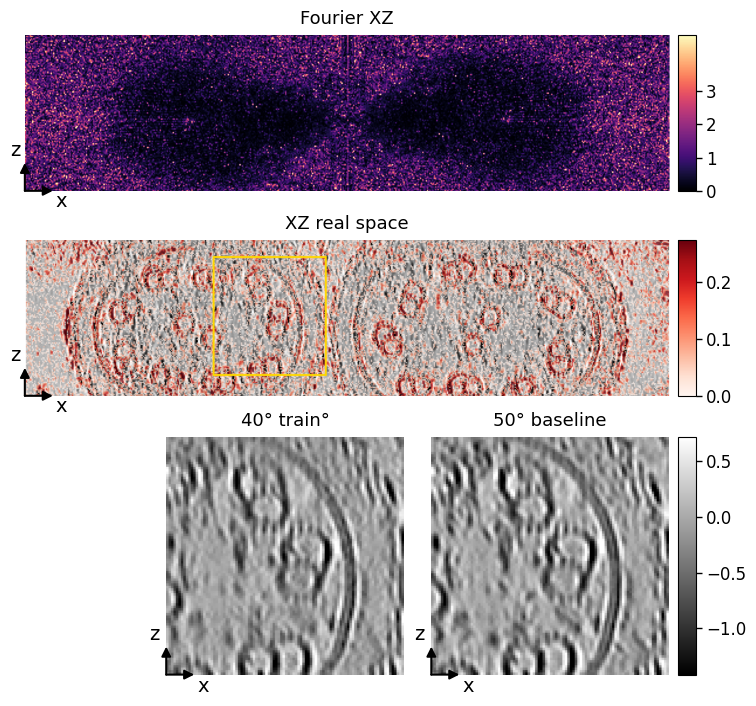

In [18]:
plt.close("all")

fig = plt.figure(figsize=(7.8, 8.2))

# ------------------------------------------------------------
# Global layout
# ------------------------------------------------------------
left_margin = 0.08
right_margin = 0.06

cb_gap = 0.012
cb_w = 0.022

main_left = left_margin
main_w = 1.0 - left_margin - right_margin - cb_gap - cb_w

# ------------------------------------------------------------
# Make Fourier/XZ a bit flatter so zooms can be larger
# ------------------------------------------------------------
ft_y, ft_h = 0.72, 0.19
xz_y, xz_h = 0.47, 0.19

rect_ft = [main_left, ft_y, main_w, ft_h]
rect_xz = [main_left, xz_y, main_w, xz_h]

rect_cb_ft = [main_left + main_w + cb_gap, ft_y, cb_w, ft_h]
rect_cb_xz = [main_left + main_w + cb_gap, xz_y, cb_w, xz_h]



# ------------------------------------------------------------
# Zoom layout
# Right zoom should end exactly below the right edge of the
# main image above (not centered group anymore)
# ------------------------------------------------------------

fig_w, fig_h = fig.get_size_inches()

zoom_y = 0.13
zoom_h = 0.29
zoom_gap = 0.035

# make zoom panels physically square
zoom_w = zoom_h * (fig_h / fig_w)

main_right = main_left + main_w

# right zoom ends exactly at the right edge of the main image
rect_zoom_right = [
    main_right - zoom_w,
    zoom_y,
    zoom_w,
    zoom_h
]

# left zoom placed left of it with fixed gap
rect_zoom_left = [
    rect_zoom_right[0] - zoom_gap - zoom_w,
    zoom_y,
    zoom_w,
    zoom_h
]

# zoom colorbar directly below the other two colorbars
rect_cb_zoom = [
    main_left + main_w + cb_gap,
    zoom_y,
    cb_w,
    zoom_h
]





# ------------------------------------------------------------
# Prepare images
# Keep crops for Fourier and XZ
# DO NOT crop zooms
# ------------------------------------------------------------

img_ft = crop_to_box_aspect_left_center_y(imgs["Fourier"], rect_ft)
img_xz = crop_to_box_aspect_left_center_y(imgs["XZ"], rect_xz)



# DO NOT crop the zooms
img_zoom_left = imgs["Zoom_left"]
img_zoom_right = imgs["Zoom_right"]




# ------------------------------------------------------------
# Draw panels
# ------------------------------------------------------------
ax_ft = show_panel(fig, img_ft, rect_ft)
ax_xz = show_panel(fig, img_xz, rect_xz)

ax_zoom_left = show_zoom_panel(fig, img_zoom_left, rect_zoom_left)
ax_zoom_right = show_zoom_panel(fig, img_zoom_right, rect_zoom_right)



# ------------------------------------------------------------
# Colorbar mappables
# ------------------------------------------------------------
real_sm = cm.ScalarMappable(norm=real_norm, cmap=overlay_cmap)
real_sm.set_array([])

fourier_norm = colors.Normalize(vmin=fourier_vmin, vmax=fourier_vmax)
fourier_sm = cm.ScalarMappable(norm=fourier_norm, cmap=fourier_cmap)
fourier_sm.set_array([])

zoom_norm = colors.Normalize(vmin=zoom_vmin, vmax=zoom_vmax)
zoom_sm = cm.ScalarMappable(norm=zoom_norm, cmap="gray")
zoom_sm.set_array([])



# ------------------------------------------------------------
# Vertical colorbars on the right
# ------------------------------------------------------------
cax_ft = fig.add_axes(rect_cb_ft)
cax_xz = fig.add_axes(rect_cb_xz)
cax_zoom = fig.add_axes(rect_cb_zoom)

cbar_ft = fig.colorbar(fourier_sm, cax=cax_ft, orientation="vertical")
cbar_ft.set_ticks([0, 1, 2, 3])
cbar_ft.ax.tick_params(labelsize=12, length=4, width=1)

cbar_xz = fig.colorbar(real_sm, cax=cax_xz, orientation="vertical")
cbar_xz.set_ticks([0.0, 0.1, 0.2])
cbar_xz.ax.tick_params(labelsize=12, length=4, width=1)

cbar_zoom = fig.colorbar(zoom_sm, cax=cax_zoom, orientation="vertical")
cbar_zoom.ax.tick_params(labelsize=12, length=4, width=1)



# optional: labels
# cbar_ft.set_label("log power", rotation=270, labelpad=16, fontsize=12)
# cbar_xz.set_label("abs. diff.", rotation=270, labelpad=16, fontsize=12)

# ------------------------------------------------------------
# Small panel titles (optional but useful in a report)
# ------------------------------------------------------------
ax_ft.set_title("Fourier XZ", fontsize=13, pad=8)
ax_xz.set_title("XZ real space", fontsize=13, pad=8)
ax_zoom_left.set_title(f"{condition}°", fontsize=13, pad=8)
ax_zoom_right.set_title("50° baseline", fontsize=13, pad=8)

# ------------------------------------------------------------
# Axis icons only where needed
# ------------------------------------------------------------


#delete above if new works
draw_axis_icon_equal(ax_ft, fig, arrow_len_in=0.28, fontsize=14, lw=1.5)
draw_axis_icon_equal(ax_xz, fig, arrow_len_in=0.28, fontsize=14, lw=1.5)
draw_axis_icon_equal_zoom(ax_zoom_left, fig, arrow_len_in=0.28, fontsize=14, lw=1.5)
draw_axis_icon_equal_zoom(ax_zoom_right, fig, arrow_len_in=0.28, fontsize=14, lw=1.5)

plt.show()

### Export

In [19]:
save_png = export_dir / f"{case_name}.png"
save_pdf = export_dir / f"{case_name}.pdf"

fig.savefig(
    save_png,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white"
)

fig.savefig(
    save_pdf,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white"
)

print("Saved:", save_png)
print("Saved:", save_pdf)

Saved: ..\..\figures\final_report\subexp02\v2\subexp02_train40_vs_train50_difference_maps.png
Saved: ..\..\figures\final_report\subexp02\v2\subexp02_train40_vs_train50_difference_maps.pdf
